# PIMA INDIANS DIABETES PREDICTION - ADVANCED INDUSTRY LEVEL (2026 Ready)
## WITH SHAP EXPLAINABILITY


# Author: Sojib Roy
## Features:
##   - Advanced feature engineering (interaction + ratio features)
##   - Outlier treatment
##   - XGBoost + LightGBM soft voting ensemble
##   - Full evaluation + visualization
##   - SHAP explainability (Feature importance + Individual predictions)
##   - Production-ready single prediction function


# 1. Imports & Configuration 

In [469]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report, confusion_matrix)
from sklearn.ensemble import VotingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap  # SHAP library for explainability
import joblib
import os
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", context="talk")
RANDOM_STATE = 42

# 2. Data Loading & Basic Checks 

In [471]:
DATA_PATH = "diabetes.csv" 

df = pd.read_csv(DATA_PATH)

In [472]:
 df.shape

(768, 9)

In [473]:
 df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [474]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [475]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [476]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# 3. Zero Values - Missing Values Treatment 

In [478]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\nZero count before replacement:")
for col in zero_as_missing:
    print(f"{col}: {(df[col] == 0).sum()} zeros")
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)


Zero count before replacement:
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


# 4. Advanced Imputation (Group-wise Median)

In [480]:
for col in zero_as_missing:
    df[col] = df.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

print("\nMissing values after imputation:", df.isnull().sum().sum())


Missing values after imputation: 0


# 5. Outlier Handling (Capping At 99th Percentile)

In [482]:
outlier_cols = ["Insulin", "DiabetesPedigreeFunction", "BMI"]
for col in outlier_cols:
    q99 = df[col].quantile(0.99)
    df[col] = np.where(df[col] > q99, q99, df[col])
    print(f"{col} capped at 99th percentile: {q99:.2f}")

Insulin capped at 99th percentile: 519.90
DiabetesPedigreeFunction capped at 99th percentile: 1.70
BMI capped at 99th percentile: 50.76


# 6. Feature Engineering 

In [484]:

# Clinically meaningful interactions & ratios
df["Glucose_Insulin_ratio"] = df["Glucose"] / (df["Insulin"] + 1e-6)
df["BMI_Age"] = df["BMI"] * df["Age"]
df["Glucose_BMI"] = df["Glucose"] * df["BMI"]
df["Pregnancies_Age"] = df["Pregnancies"] / (df["Age"] + 1e-6)
df["Insulin_per_Pregnancy"] = df["Insulin"] / (df["Pregnancies"] + 1)

# Categorical features
df["Glucose_status"] = pd.cut(df["Glucose"], 
                              bins=[0, 100, 125, 200], 
                              labels=["normal", "prediabetes", "diabetes"])

df["BMI_status"] = pd.cut(df["BMI"], 
                          bins=[0, 18.5, 25, 30, 100], 
                          labels=["underweight", "normal", "overweight", "obese"])

# One-hot encoding
df = pd.get_dummies(df, columns=["Glucose_status", "BMI_status"], drop_first=True)

print("\nColumns after feature engineering:", df.columns.tolist())


Columns after feature engineering: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_Insulin_ratio', 'BMI_Age', 'Glucose_BMI', 'Pregnancies_Age', 'Insulin_per_Pregnancy', 'Glucose_status_prediabetes', 'Glucose_status_diabetes', 'BMI_status_normal', 'BMI_status_overweight', 'BMI_status_obese']


# 7. Train-test Split 

In [486]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

#Scaling (optional for tree models, but good to have)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train shape: (614, 18)
Test shape: (154, 18)


# 8. Model Definition - Xgboost + Lightgbm Ensemble 

In [488]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    verbosity=0)

lgb = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.06,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=RANDOM_STATE,
    verbose=-1)

# Soft Voting Ensemble (probability average)
ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('lgb', lgb)],
    voting='soft',
    weights=[0.6, 0.4])

# 9. Final Model Training & Evaluation 

In [490]:
ensemble.fit(X_train_scaled, y_train)

y_pred = ensemble.predict(X_test_scaled)
y_proba = ensemble.predict_proba(X_test_scaled)[:, 1]

print("FINAL ENSEMBLE PERFORMANCE (XGBoost + LightGBM)")
print(f"Accuracy:       {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:      {precision_score(y_test, y_pred):.4f}")
print(f"Recall:         {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:       {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:        {roc_auc_score(y_test, y_proba):.4f}")

FINAL ENSEMBLE PERFORMANCE (XGBoost + LightGBM)
Accuracy:       0.8896
Precision:      0.8364
Recall:         0.8519
F1-Score:       0.8440
ROC-AUC:        0.9511


In [491]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       100
           1       0.84      0.85      0.84        54

    accuracy                           0.89       154
   macro avg       0.88      0.88      0.88       154
weighted avg       0.89      0.89      0.89       154



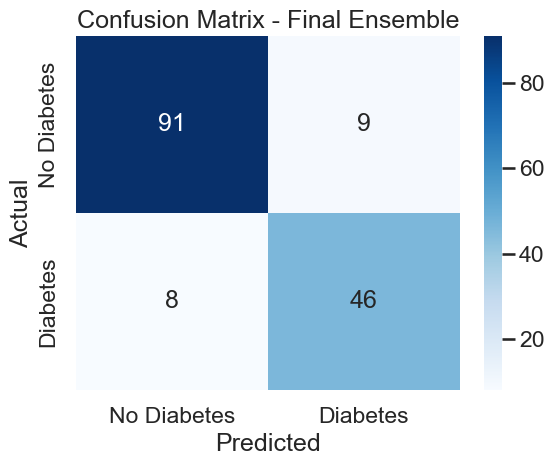

In [492]:
# Confusion Matrix Visualization
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix - Final Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 10. Cross-validation Check

In [494]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    ensemble,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    error_score="raise")

print("\n5-Fold CV ROC-AUC scores:", cv_scores)
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-Fold CV ROC-AUC scores: [0.92877907 0.93517442 0.96453488 0.94883721 0.9389881 ]
Mean CV ROC-AUC: 0.9433 ± 0.0125


# 11. Shap Explainability

In [496]:
print("SHAP EXPLAINABILITY ANALYSIS")

# SHAP works best with individual models, so we'll explain XGBoost (dominant model)
xgb_model = ensemble.estimators_[0]  # Extract trained XGBoost

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

SHAP EXPLAINABILITY ANALYSIS


# 11.1 Global Feature Importance (Summary Plot)


[SHAP] Generating global feature importance plot...


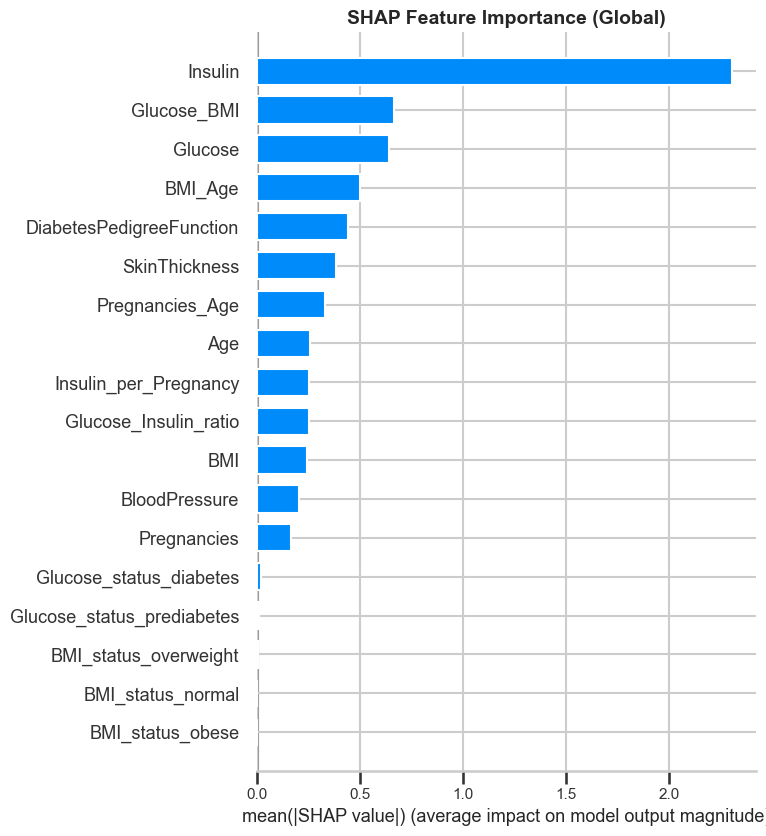

In [498]:
print("\n[SHAP] Generating global feature importance plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", 
                  feature_names=X.columns, show=False)
plt.title("SHAP Feature Importance (Global)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#  11.2 Detailed Summary Plot (Feature Impact) 

[SHAP] Generating detailed summary plot...


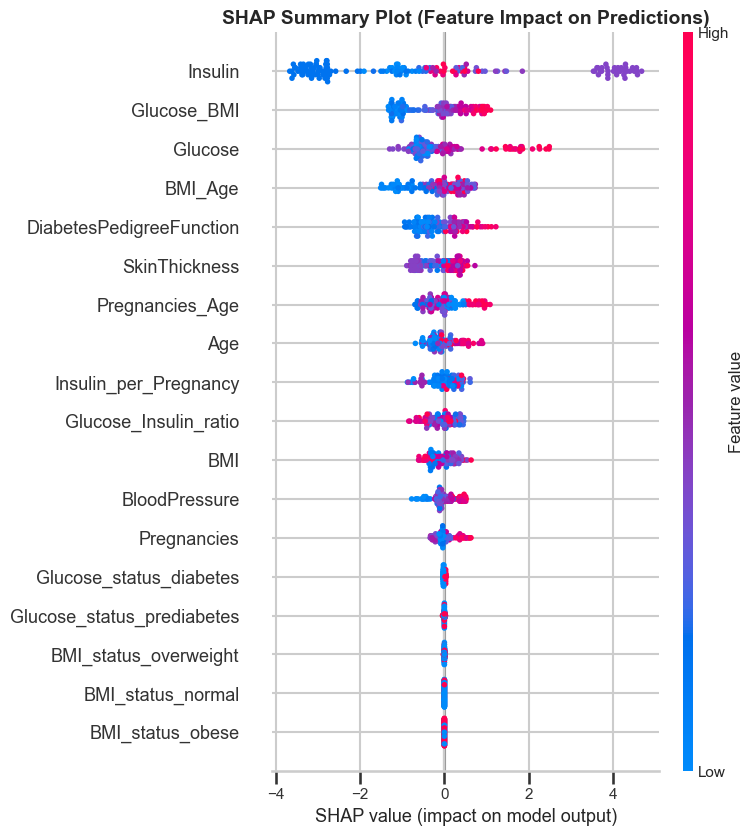

In [500]:
print("[SHAP] Generating detailed summary plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot (Feature Impact on Predictions)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 11.3 Individual Prediction Explanation (Waterfall) 

In [502]:
# Example: Explain first test sample
print("\n[SHAP] Explaining individual prediction (Patient Index 0)...")
sample_idx = 0
shap_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx],
    feature_names=X.columns.tolist())


[SHAP] Explaining individual prediction (Patient Index 0)...


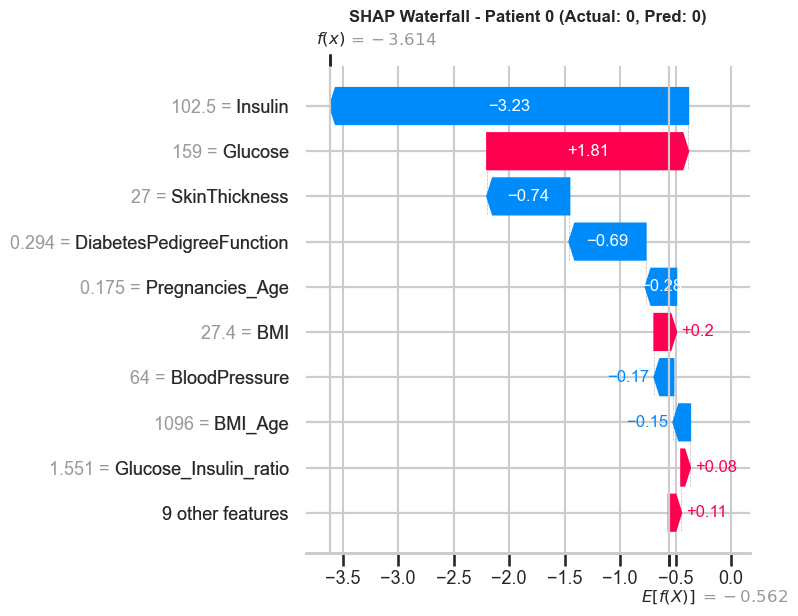

In [503]:
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, show=False)
plt.title(f"SHAP Waterfall - Patient {sample_idx} (Actual: {y_test.iloc[sample_idx]}, Pred: {y_pred[sample_idx]})", 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 11.4 Force Plot (Interactive - Single Prediction) 

In [505]:
print("[SHAP] Generating force plot for single prediction...")
shap.initjs()  # Initialize JavaScript for visualization
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    feature_names=X.columns.tolist()
)
# Note: Force plot best viewed in Jupyter notebook. For script, we save as HTML
shap.save_html("shap_force_plot.html", force_plot)
print("✅ Force plot saved as 'shap_force_plot.html'")

[SHAP] Generating force plot for single prediction...


✅ Force plot saved as 'shap_force_plot.html'


# 11.5 DEPENDENCE PLOT (Feature Interaction)


[SHAP] Generating dependence plot for Glucose...


<Figure size 800x600 with 0 Axes>

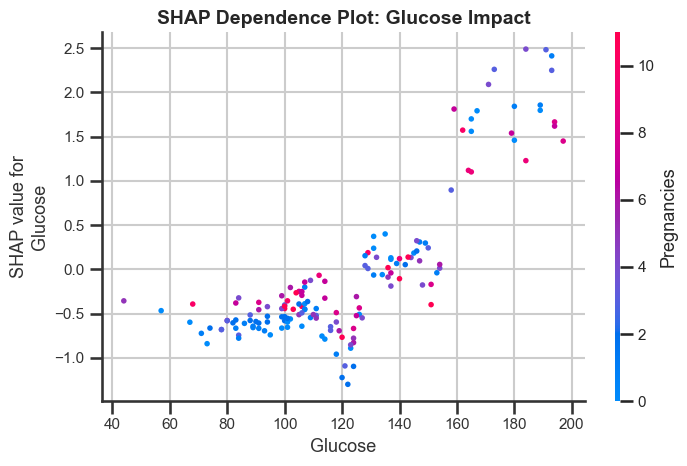

In [507]:
# Example: How Glucose affects prediction
print("\n[SHAP] Generating dependence plot for Glucose...")
plt.figure(figsize=(8, 6))
shap.dependence_plot("Glucose", shap_values, X_test, 
                     feature_names=X.columns, show=False)
plt.title("SHAP Dependence Plot: Glucose Impact", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 11.6 Top Features Interpretation 

In [509]:
# Calculate mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mean_shap
}).sort_values('Importance', ascending=False)

print("TOP 10 MOST IMPORTANT FEATURES (SHAP)")
print(feature_importance_df.head(10).to_string(index=False))

TOP 10 MOST IMPORTANT FEATURES (SHAP)
                 Feature  Importance
                 Insulin    2.307727
             Glucose_BMI    0.667724
                 Glucose    0.640330
                 BMI_Age    0.499972
DiabetesPedigreeFunction    0.440327
           SkinThickness    0.385850
         Pregnancies_Age    0.328481
                     Age    0.257604
   Insulin_per_Pregnancy    0.254920
   Glucose_Insulin_ratio    0.253670


# 12. Model Saving 

In [511]:
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(ensemble, os.path.join(ARTIFACTS_DIR, "diabetes_ensemble_model.joblib"))
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, "scaler.joblib"))
joblib.dump(explainer, os.path.join(ARTIFACTS_DIR, "shap_explainer.joblib"))  # Save SHAP explainer
np.save(os.path.join(ARTIFACTS_DIR, "feature_columns.npy"), X.columns.to_numpy())

print(f"\n✅ Model, Scaler & SHAP Explainer saved in '{ARTIFACTS_DIR}' folder!")


✅ Model, Scaler & SHAP Explainer saved in 'artifacts' folder!


# 13. Single Prediction Function With Shap 

In [513]:
def predict_diabetes_with_explanation(input_dict, show_shap=True):
    """
    Predict diabetes with SHAP explanation
    
    Parameters:
    -----------
    input_dict : dict
        Patient data with keys: Pregnancies, Glucose, BloodPressure, etc.
    show_shap : bool
        If True, displays SHAP waterfall plot for the prediction
    
    Returns:
    --------
    dict with prediction, probability, message, and SHAP values
    """
    # Load saved objects
    model = joblib.load(os.path.join(ARTIFACTS_DIR, "diabetes_ensemble_model.joblib"))
    scaler = joblib.load(os.path.join(ARTIFACTS_DIR, "scaler.joblib"))
    explainer = joblib.load(os.path.join(ARTIFACTS_DIR, "shap_explainer.joblib"))
    feature_cols = np.load(os.path.join(ARTIFACTS_DIR, "feature_columns.npy"), allow_pickle=True)
    
    # Create dataframe from input
    df_input = pd.DataFrame([input_dict])
    
    # Same preprocessing pipeline
    df_input[zero_as_missing] = df_input[zero_as_missing].replace(0, np.nan)
    
    # Impute missing values with global medians (since we don't have group info for single prediction)
    for col in zero_as_missing:
        if col in df_input.columns:
            df_input[col].fillna(df[col].median(), inplace=True)
    
    # Feature Engineering (must match training)
    df_input["Glucose_Insulin_ratio"] = df_input["Glucose"] / (df_input["Insulin"] + 1e-6)
    df_input["BMI_Age"] = df_input["BMI"] * df_input["Age"]
    df_input["Glucose_BMI"] = df_input["Glucose"] * df_input["BMI"]
    df_input["Pregnancies_Age"] = df_input["Pregnancies"] / (df_input["Age"] + 1e-6)
    df_input["Insulin_per_Pregnancy"] = df_input["Insulin"] / (df_input["Pregnancies"] + 1)
    
    df_input["Glucose_status"] = pd.cut(df_input["Glucose"], 
                                        bins=[0, 100, 125, 200], 
                                        labels=["normal", "prediabetes", "diabetes"])
    
    df_input["BMI_status"] = pd.cut(df_input["BMI"], 
                                    bins=[0, 18.5, 25, 30, 100], 
                                    labels=["underweight", "normal", "overweight", "obese"])
    
    df_input = pd.get_dummies(df_input, columns=["Glucose_status", "BMI_status"], drop_first=True)
    
    # Align columns with training
    df_input = df_input.reindex(columns=feature_cols, fill_value=0)
    
    # Scale & predict
    input_scaled = scaler.transform(df_input)
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0, 1]
    
    # SHAP Explanation
    xgb_model = model.estimators_[0]  # Extract XGBoost
    shap_values = explainer.shap_values(input_scaled)
    
    # Create SHAP explanation object
    shap_exp = shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=df_input.iloc[0],
        feature_names=feature_cols.tolist()
    )
    
    # Display SHAP waterfall if requested
    if show_shap:
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(shap_exp, show=False)
        plt.title(f"SHAP Explanation - Prediction: {prediction} (Prob: {probability:.2%})", 
                  fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # Top contributing features
    shap_contrib = pd.DataFrame({
        'Feature': feature_cols,
        'SHAP_Value': shap_values[0]
    }).sort_values('SHAP_Value', key=abs, ascending=False).head(5)
    
    return {
        "prediction": int(prediction),
        "probability": float(probability),
        "message": "⚠️ Diabetes Detected" if prediction == 1 else "✅ No Diabetes",
        "top_contributors": shap_contrib.to_dict('records')
    }

# 14. Test Single Prediction With Shap


TESTING SINGLE PREDICTION WITH SHAP EXPLANATION


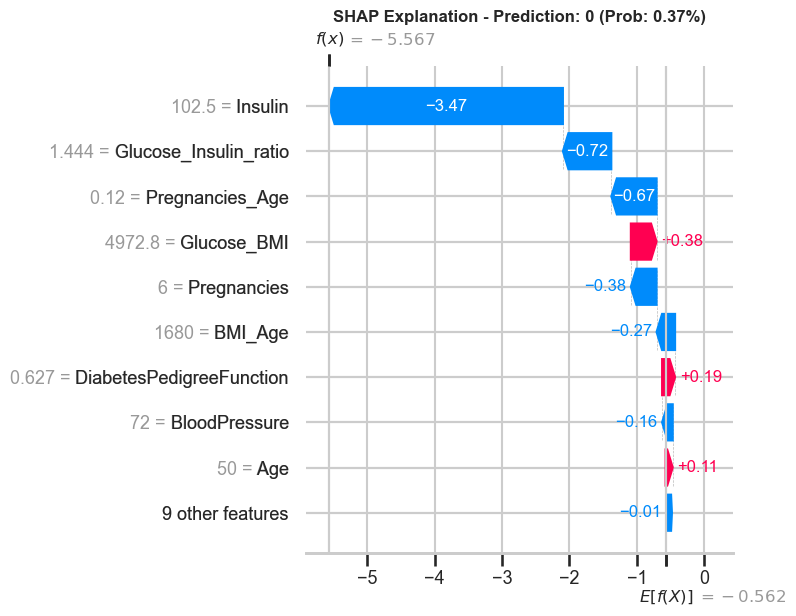


📊 PREDICTION RESULT:
  Prediction: 0
  Probability: 0.37%
  Message: ✅ No Diabetes

🔍 TOP 5 CONTRIBUTING FEATURES:
  1. Insulin: -3.4694 (decreases risk)
  2. Glucose_Insulin_ratio: -0.7183 (decreases risk)
  3. Pregnancies_Age: -0.6714 (decreases risk)
  4. Glucose_BMI: 0.3819 (increases risk)
  5. Pregnancies: -0.3816 (decreases risk)


In [515]:
if __name__ == "__main__":
    print("\n" + "="*60)
    print("TESTING SINGLE PREDICTION WITH SHAP EXPLANATION")
    print("="*60)
    
    example = {
        "Pregnancies": 6,
        "Glucose": 148,
        "BloodPressure": 72,
        "SkinThickness": 35,
        "Insulin": 0,
        "BMI": 33.6,
        "DiabetesPedigreeFunction": 0.627,
        "Age": 50
    }
    
    result = predict_diabetes_with_explanation(example, show_shap=True)
    
    print("\n📊 PREDICTION RESULT:")
    print(f"  Prediction: {result['prediction']}")
    print(f"  Probability: {result['probability']:.2%}")
    print(f"  Message: {result['message']}")
    print(f"\n🔍 TOP 5 CONTRIBUTING FEATURES:")
    for i, contrib in enumerate(result['top_contributors'], 1):
        impact = "increases" if contrib['SHAP_Value'] > 0 else "decreases"
        print(f"  {i}. {contrib['Feature']}: {contrib['SHAP_Value']:.4f} ({impact} risk)")